In [1]:
import nltk
import random
import math
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

nltk.download('brown')
nltk.download('reuters')
nltk.download('punkt')


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\vishn\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package reuters to
[nltk_data]     C:\Users\vishn\AppData\Roaming\nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vishn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
from nltk.corpus import brown, reuters

# Corpus 1: Brown (news)
corpus1 = brown.words(categories='news')

# Corpus 2: Reuters (trade)
corpus2 = reuters.words(categories='trade')


In [3]:
def preprocess(corpus):
    return [w.lower() for w in corpus if w.isalpha()]

tokens1 = preprocess(corpus1)
tokens2 = preprocess(corpus2)


In [4]:
def generate_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

unigrams1 = tokens1
unigrams2 = tokens2

bigrams1 = generate_ngrams(tokens1, 2)
bigrams2 = generate_ngrams(tokens2, 2)


In [5]:
uni_freq1 = Counter(unigrams1)
uni_freq2 = Counter(unigrams2)

top_uni1 = uni_freq1.most_common(10)
top_uni2 = uni_freq2.most_common(10)

print("Top Unigrams – Brown News:", top_uni1)
print("Top Unigrams – Reuters Trade:", top_uni2)


Top Unigrams – Brown News: [('the', 6386), ('of', 2861), ('and', 2186), ('to', 2144), ('a', 2130), ('in', 2020), ('for', 969), ('that', 829), ('is', 733), ('was', 717)]
Top Unigrams – Reuters Trade: [('the', 7177), ('to', 4270), ('of', 2980), ('in', 2967), ('and', 2520), ('s', 2449), ('a', 2368), ('said', 2181), ('trade', 2034), ('u', 1452)]


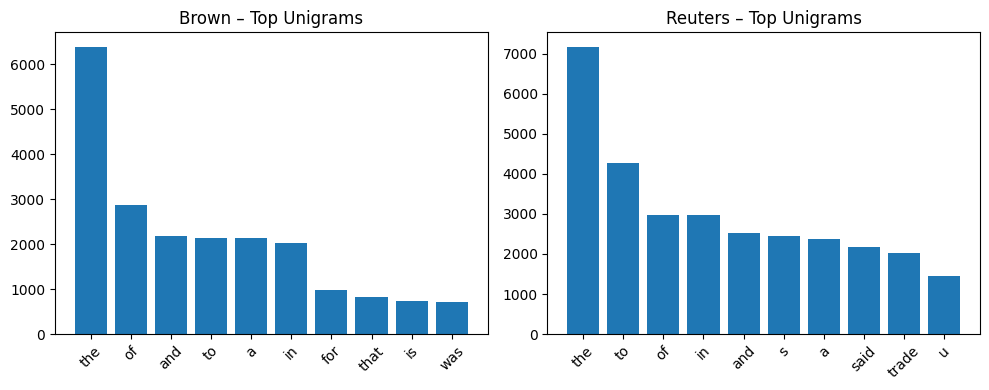

In [6]:
words1, counts1 = zip(*top_uni1)
words2, counts2 = zip(*top_uni2)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(words1, counts1)
plt.title("Brown – Top Unigrams")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
plt.bar(words2, counts2)
plt.title("Reuters – Top Unigrams")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [7]:
bi_freq1 = Counter(bigrams1)
bi_freq2 = Counter(bigrams2)

print("Top Bigrams – Brown:", bi_freq1.most_common(10))
print("Top Bigrams – Reuters:", bi_freq2.most_common(10))


Top Bigrams – Brown: [(('of', 'the'), 850), (('in', 'the'), 610), (('to', 'the'), 279), (('on', 'the'), 258), (('for', 'the'), 223), (('at', 'the'), 204), (('will', 'be'), 157), (('that', 'the'), 149), (('and', 'the'), 142), (('with', 'the'), 142)]
Top Bigrams – Reuters: [(('u', 's'), 1409), (('in', 'the'), 709), (('of', 'the'), 662), (('the', 'u'), 569), (('said', 'the'), 528), (('he', 'said'), 429), (('billion', 'dlrs'), 414), (('to', 'the'), 333), (('the', 'united'), 260), (('united', 'states'), 258)]


In [8]:
def bigram_model(tokens):
    unigrams = Counter(tokens)
    bigrams = Counter(generate_ngrams(tokens, 2))
    vocab_size = len(unigrams)
    return unigrams, bigrams, vocab_size

uni1, bi1, V1 = bigram_model(tokens1)


In [9]:
def generate_sentence(unigrams, bigrams, length=10):
    word = random.choice(list(unigrams.keys()))
    sentence = [word]

    for _ in range(length-1):
        candidates = {bg[1]: count for bg, count in bigrams.items() if bg[0] == word}
        if not candidates:
            break
        word = random.choice(list(candidates.keys()))
        sentence.append(word)

    return " ".join(sentence)

print("Random Sentence:")
print(generate_sentence(uni1, bi1))


Random Sentence:
aerial spraying programs the studio exec makes for pedestrians was


In [10]:
def perplexity(test_tokens, unigrams, bigrams, V):
    N = len(test_tokens) - 1
    log_prob = 0

    for i in range(N):
        bigram = (test_tokens[i], test_tokens[i+1])
        bigram_count = bigrams[bigram] + 1
        unigram_count = unigrams[test_tokens[i]] + V
        prob = bigram_count / unigram_count
        log_prob += math.log(prob)

    return math.exp(-log_prob / N)


In [11]:
test_data = tokens1[:1000]   # small test set
pp = perplexity(test_data, uni1, bi1, V1)
print("Perplexity:", pp)


Perplexity: 2701.9657552281496
